In [ ]:
# %% [markdown]
# # WRF Climate Change: Delta vs Elevation
# Projected change in temperature, precipitation, and wind speed as a function of elevation
# for land grid cells in the CanESM2-WRF domain.


# %% [markdown]
# ## Configuration
# %% [markdown]
# ## Load Elevation and Land Mask

# %%

# %% [markdown]
# ## Helper Functions

# %%

# %% [markdown]
# ## Monthly Change vs Elevation
# One row per variable, one column per month

# %%


In [1]:
# %% 
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

In [2]:

# %%
domain  = 'd03'          # 'd02' or 'd03'
period  = 'rcp85'        # 'rcp45' or 'rcp85'
bin_size = 200           # elevation bin size in metres

basepath     = '/gpfs/fs7/dfo/hpcmc/pfm/spfm000/CanESM2-WRF/'
geo_em_file  = basepath + f'domain/geo_em.{domain}.nc'

variables = {
    't':    {'var': 'T2',   'filename': f't_{domain}_daily_newdim',  'units': '°C',  'label': '2 m Temperature'},
    'pr':   {'var': 'pr',   'filename': f'pr_{domain}_daily',        'units': '%',   'label': 'Precipitation'},
    'wind': {'var': 'wspd', 'filename': f'wind_{domain}_daily' if domain != 'd03' 
                                        else 'wind_d03_daily_wspd',  'units': '%',   'label': '10 m Wind Speed'},
}

month_names = ['Jan','Feb','Mar','Apr','May','Jun',
               'Jul','Aug','Sep','Oct','Nov','Dec']



In [3]:
geo       = xr.open_dataset(geo_em_file)
landmask  = geo['LANDMASK'].squeeze().values   # (nlat, nlon)
elevation = geo['HGT_M'].squeeze().values      # (nlat, nlon)
land_mask = (landmask == 1)

print(f"Domain:         {domain}")
print(f"Grid shape:     {elevation.shape}")
print(f"Elevation range: {elevation[land_mask].min():.0f} – {elevation[land_mask].max():.0f} m")
print(f"Land grid cells: {land_mask.sum()}")


Domain:         d03
Grid shape:     (300, 300)
Elevation range: 0 – 3234 m
Land grid cells: 48981


In [4]:
def load_delta(variable, period, domain):
    """Return monthly delta (12, nlat, nlon) and hist_monthly for a given variable."""
    cfg      = variables[variable]
    var      = cfg['var']
    filename = cfg['filename']

    hist_path = basepath + f'historical/variables_complete/{filename}.nc'
    fut_path  = basepath + f'{period}/variables_complete/{filename}.nc'

    var_hist = xr.open_dataset(hist_path)[var]
    var_fut  = xr.open_dataset(fut_path)[var]

    hist_monthly = var_hist.groupby('time.month').mean('time')
    fut_monthly  = var_fut.groupby('time.month').mean('time')

    delta = fut_monthly - hist_monthly   # (12, nlat, nlon)

    if variable != 't':
        delta = (delta / hist_monthly) * 100

    return delta.values, hist_monthly.values   # return numpy arrays


def bin_by_elevation(delta_2d, elevation, land_mask, bin_size=200):
    """
    Bin a 2D delta field by elevation over land grid cells.
    Returns bin_centres, bin_means, bin_stds, bin_counts.
    """
    elev_flat  = elevation[land_mask].flatten()
    delta_flat = delta_2d[land_mask].flatten()

    # Remove NaNs
    valid      = np.isfinite(delta_flat)
    elev_flat  = elev_flat[valid]
    delta_flat = delta_flat[valid]

    bin_edges   = np.arange(0, elev_flat.max() + bin_size, bin_size)
    bin_centres = (bin_edges[:-1] + bin_edges[1:]) / 2

    bin_means  = np.full(len(bin_centres), np.nan)
    bin_stds   = np.full(len(bin_centres), np.nan)
    bin_counts = np.zeros(len(bin_centres))

    for ii in range(len(bin_centres)):
        in_bin = (elev_flat >= bin_edges[ii]) & (elev_flat < bin_edges[ii+1])
        if in_bin.sum() > 2:
            bin_means[ii]  = np.nanmean(delta_flat[in_bin])
            bin_stds[ii]   = np.nanstd(delta_flat[in_bin])
            bin_counts[ii] = in_bin.sum()

    return bin_centres, bin_means, bin_stds, bin_counts



/home/amh001/space_fs7/software_2022/python/py_2024/lib/python3.9/site-packages/xarray/coding/times.py:242: CFWarning: this date/calendar/year zero convention is not supported by CF
  cftime.num2date(num_dates, units, calendar, only_use_cftime_datetimes=True)
/home/amh001/space_fs7/software_2022/python/py_2024/lib/python3.9/site-packages/xarray/coding/times.py:992: SerializationWarning: Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects instead, reason: dates out of range
  dtype = _decode_cf_datetime_dtype(data, units, calendar, self.use_cftime)
/home/amh001/space_fs7/software_2022/python/py_2024/lib/python3.9/site-packages/xarray/coding/times.py:242: CFWarning: this date/calendar/year zero convention is not supported by CF
  cftime.num2date(num_dates, units, calendar, only_use_cftime_datetimes=True)
/home/amh001/space_fs7/software_2022/python/py_2024/lib/python3.9/site-packages/xarray/coding/times.py:992: SerializationWarning: Unab

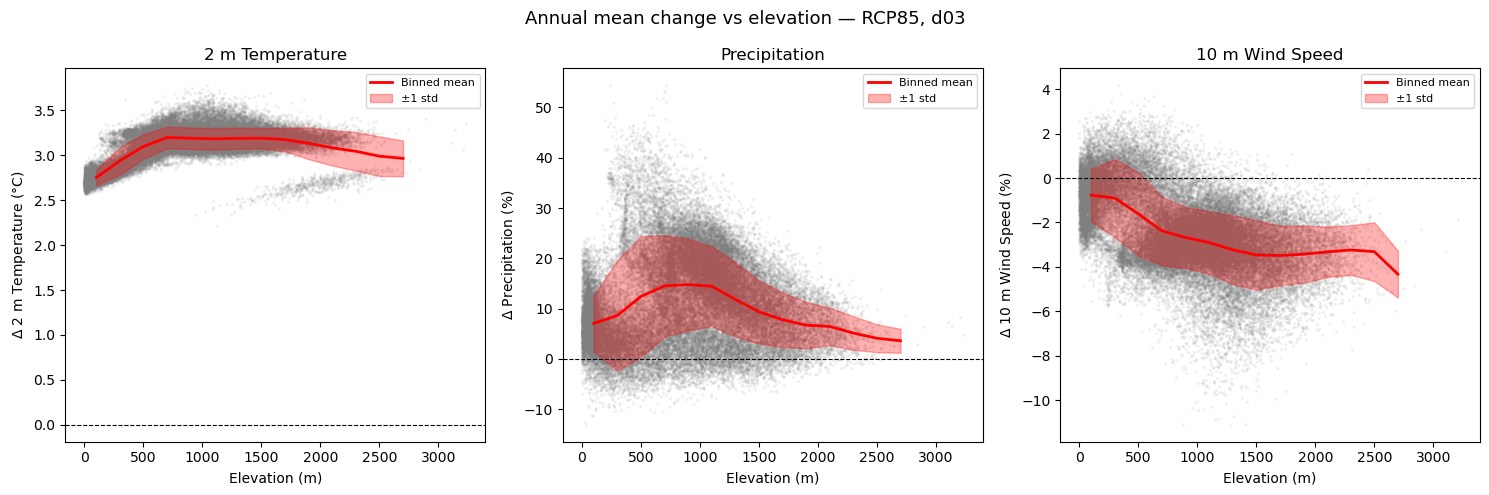

In [7]:



# %%
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, variable in zip(axes, ['t', 'pr', 'wind']):
    cfg = variables[variable]
    delta, _ = load_delta(variable, period, domain)

    # Annual mean across months
    delta_annual = delta.mean(axis=0)   # (nlat, nlon)

    centres, means, stds, counts = bin_by_elevation(
        delta_annual, elevation, land_mask, bin_size=bin_size
    )

    # Raw scatter
    elev_flat  = elevation[land_mask].flatten()
    delta_flat = delta_annual[land_mask].flatten()
    ax.scatter(elev_flat, delta_flat, alpha=0.08, s=2, color='grey', rasterized=True)

    # Binned mean ± 1 std
    ax.plot(centres, means, color='red', linewidth=2, label='Binned mean')
    ax.fill_between(centres,
                    means - stds,
                    means + stds,
                    alpha=0.3, color='red', label='±1 std')

    ax.axhline(0, color='black', linestyle='--', linewidth=0.8)
    ax.set_xlabel('Elevation (m)')
    ax.set_ylabel(f'$\\Delta$ {cfg["label"]} ({cfg["units"]})')
    ax.set_title(cfg['label'])
    ax.legend(fontsize=8)

fig.suptitle(f'Annual mean change vs elevation — {period.upper()}, {domain}', fontsize=13)
plt.tight_layout()
#plt.savefig(f'delta_vs_elevation_annual_{period}_{domain}.png', dpi=150)
plt.show()


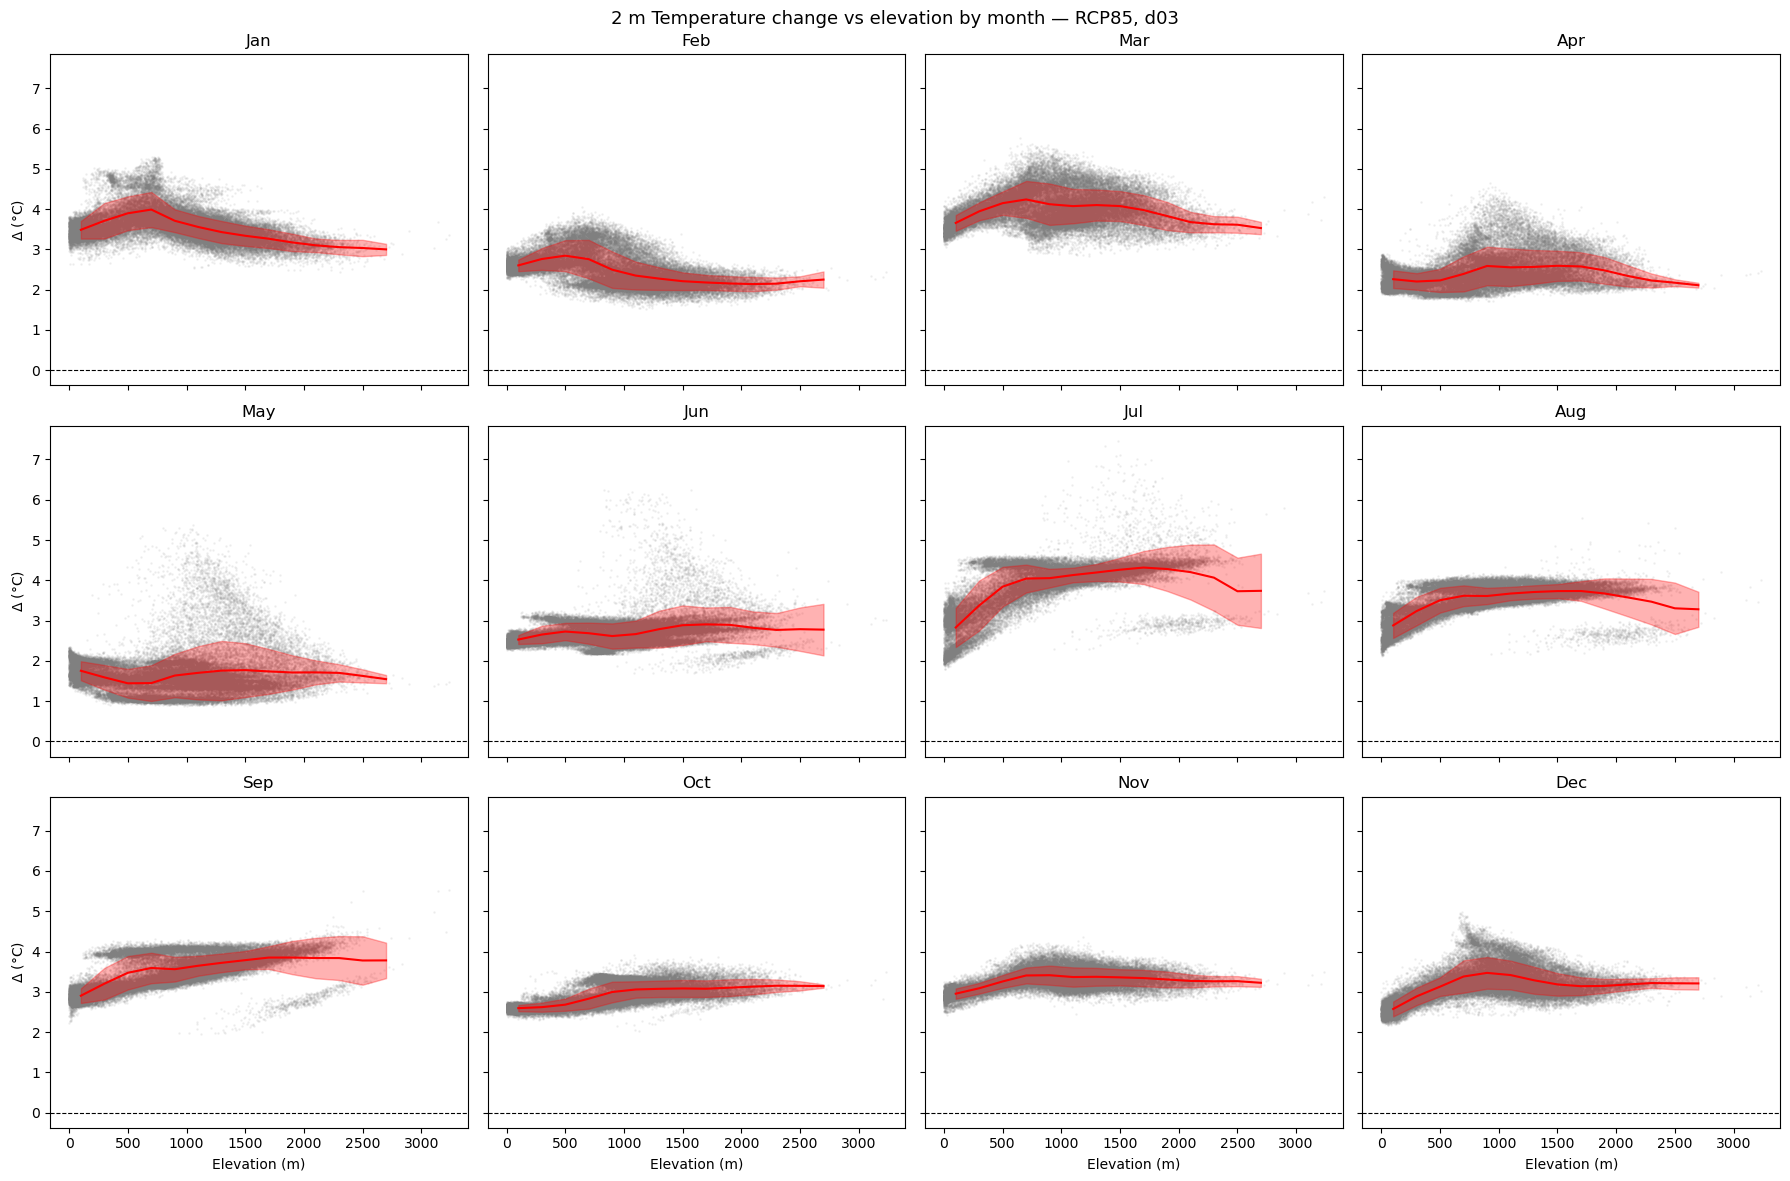

/home/amh001/space_fs7/software_2022/python/py_2024/lib/python3.9/site-packages/xarray/coding/times.py:242: CFWarning: this date/calendar/year zero convention is not supported by CF
  cftime.num2date(num_dates, units, calendar, only_use_cftime_datetimes=True)
/home/amh001/space_fs7/software_2022/python/py_2024/lib/python3.9/site-packages/xarray/coding/times.py:992: SerializationWarning: Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects instead, reason: dates out of range
  dtype = _decode_cf_datetime_dtype(data, units, calendar, self.use_cftime)
/home/amh001/space_fs7/software_2022/python/py_2024/lib/python3.9/site-packages/xarray/coding/times.py:242: CFWarning: this date/calendar/year zero convention is not supported by CF
  cftime.num2date(num_dates, units, calendar, only_use_cftime_datetimes=True)
/home/amh001/space_fs7/software_2022/python/py_2024/lib/python3.9/site-packages/xarray/coding/times.py:992: SerializationWarning: Unab

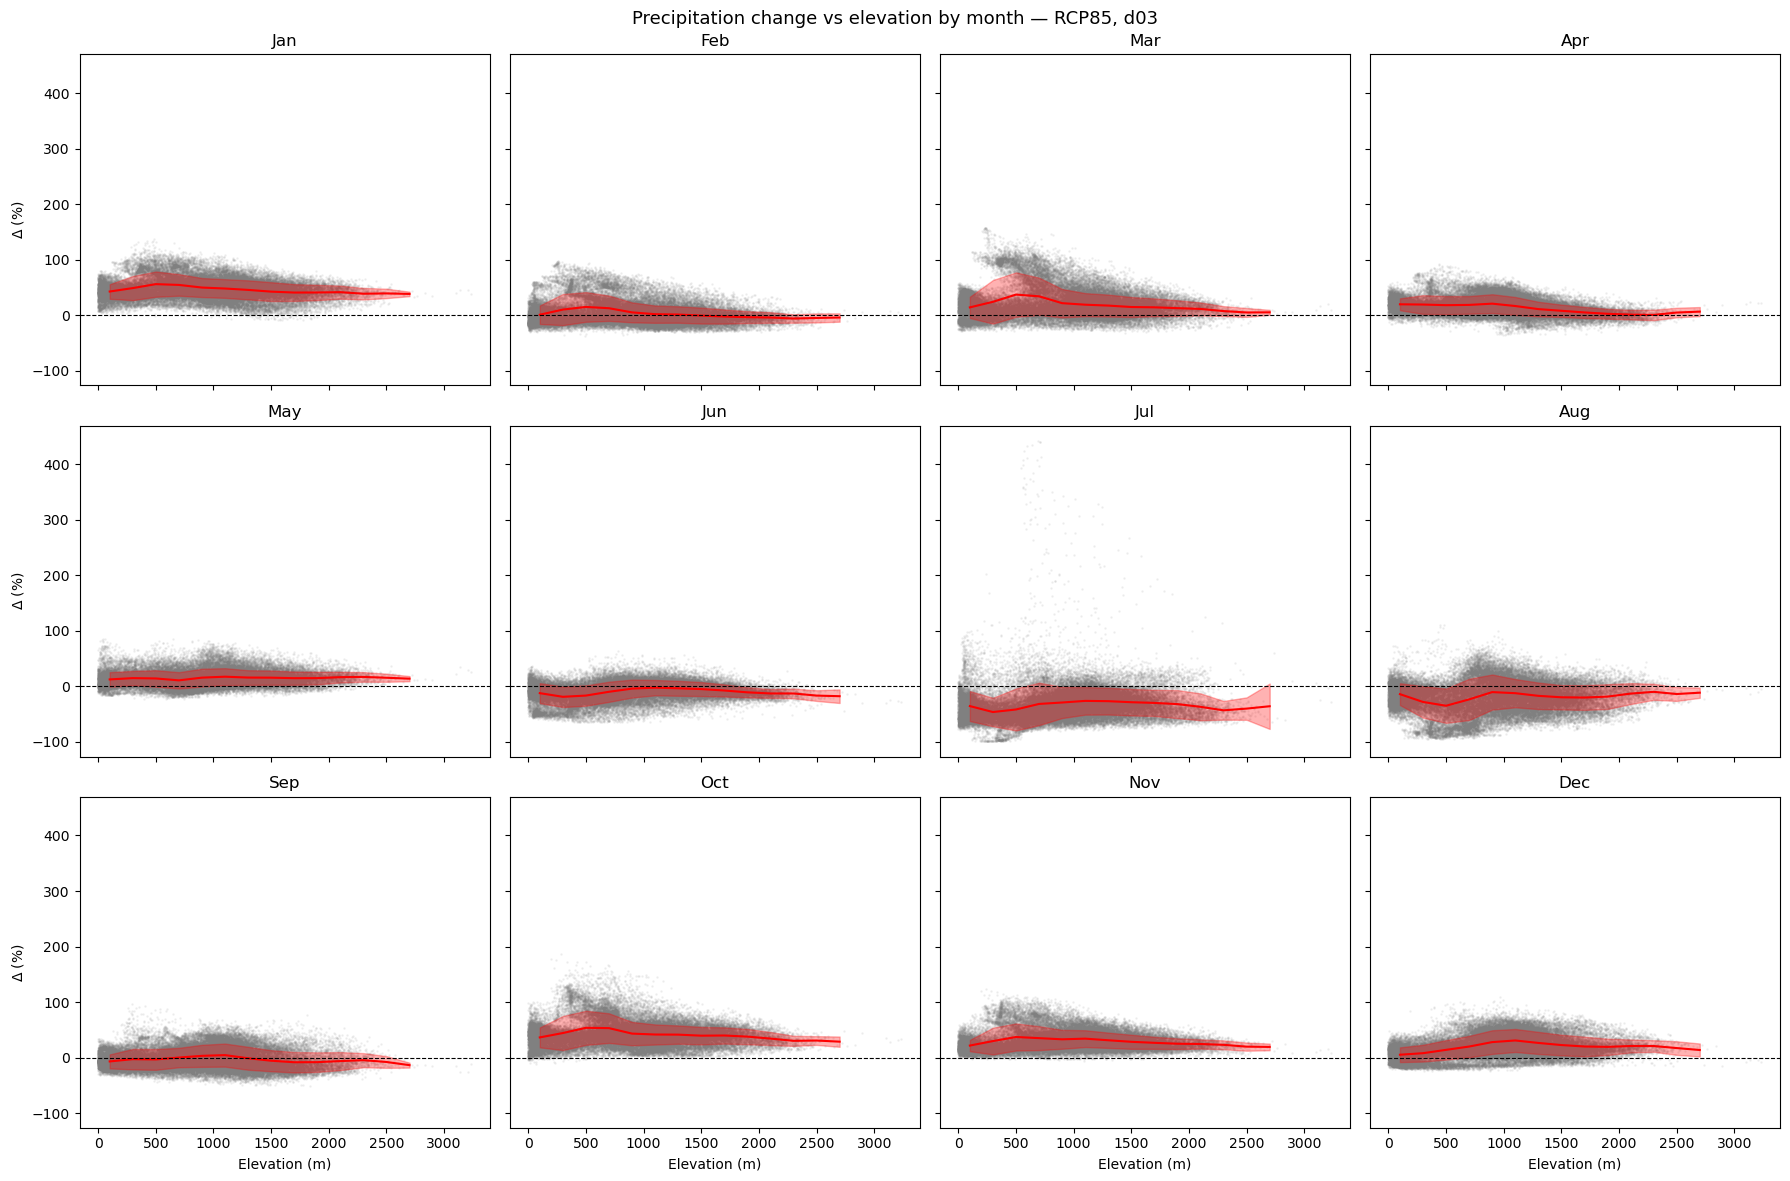

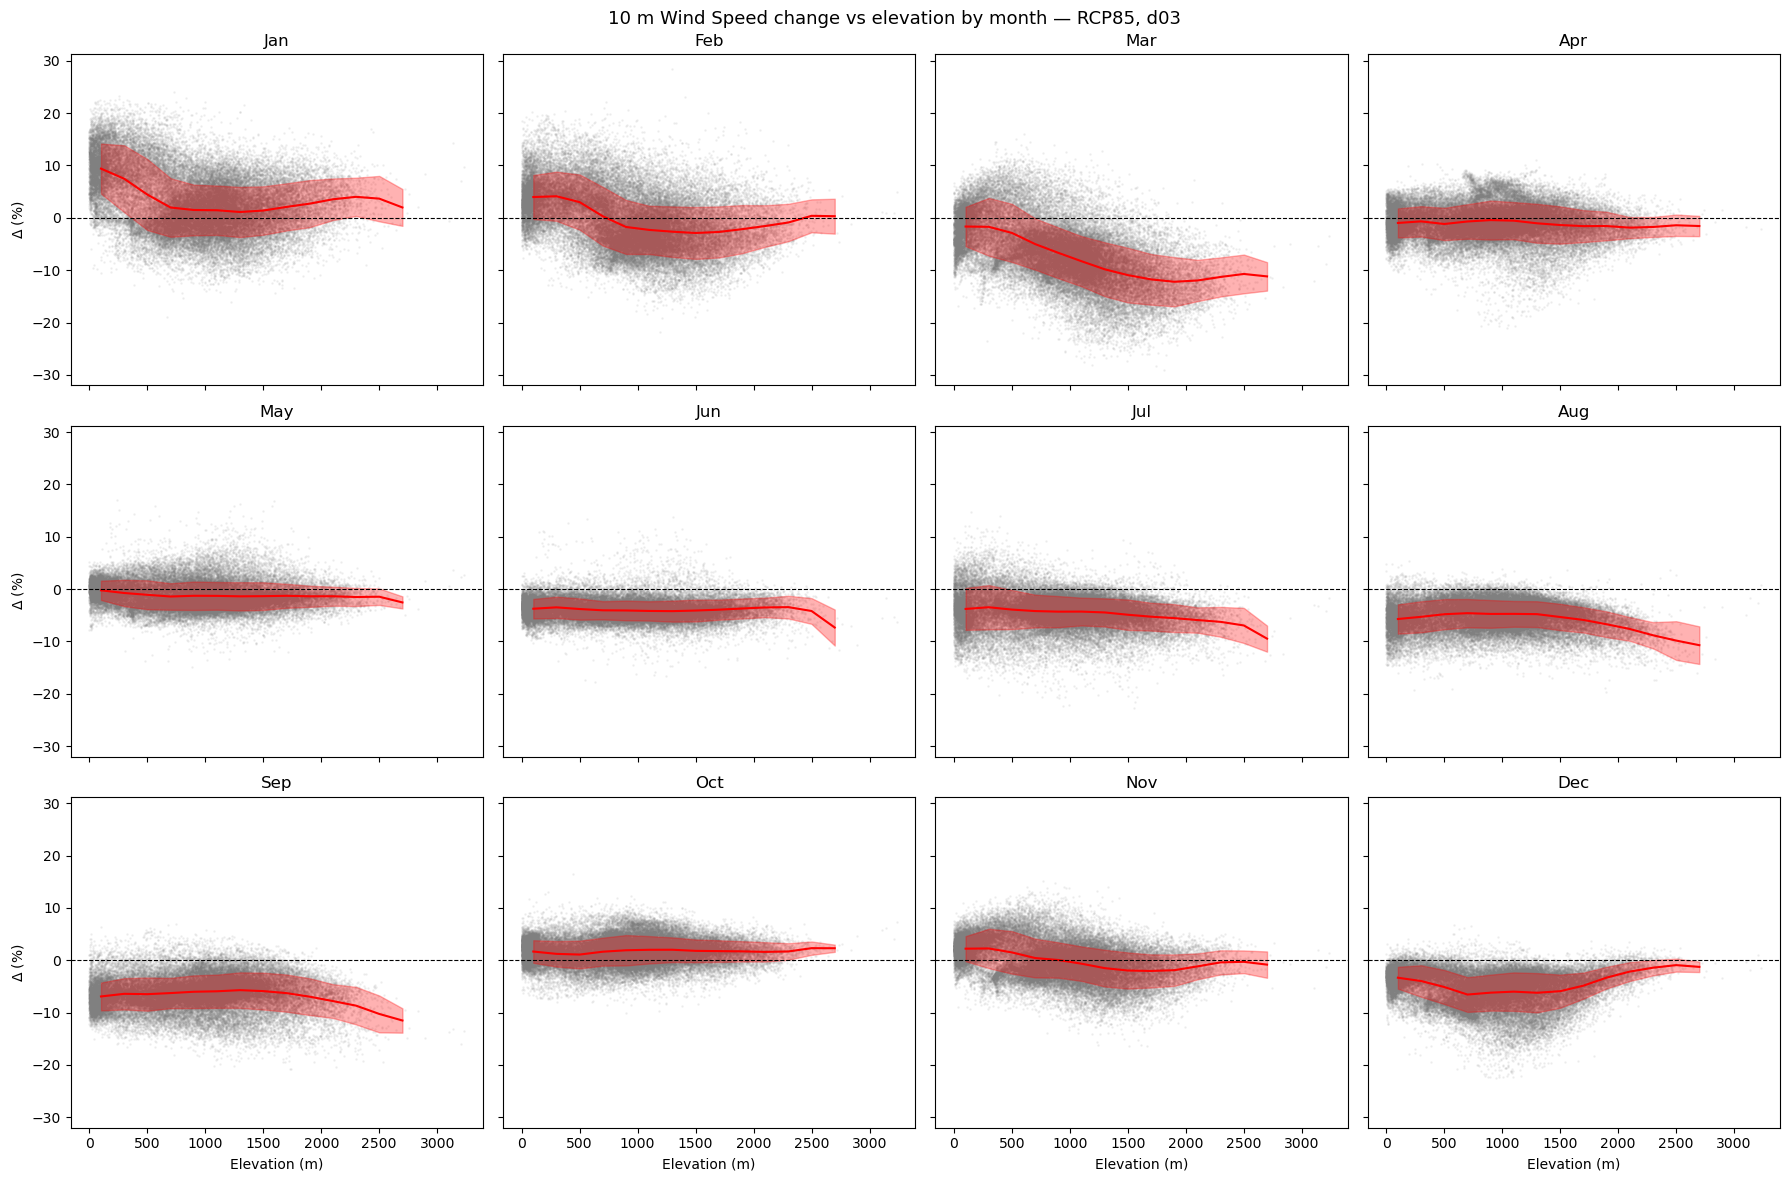

/home/amh001/space_fs7/software_2022/python/py_2024/lib/python3.9/site-packages/xarray/coding/times.py:242: CFWarning: this date/calendar/year zero convention is not supported by CF
  cftime.num2date(num_dates, units, calendar, only_use_cftime_datetimes=True)
/home/amh001/space_fs7/software_2022/python/py_2024/lib/python3.9/site-packages/xarray/coding/times.py:992: SerializationWarning: Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects instead, reason: dates out of range
  dtype = _decode_cf_datetime_dtype(data, units, calendar, self.use_cftime)
/home/amh001/space_fs7/software_2022/python/py_2024/lib/python3.9/site-packages/xarray/coding/times.py:242: CFWarning: this date/calendar/year zero convention is not supported by CF
  cftime.num2date(num_dates, units, calendar, only_use_cftime_datetimes=True)
/home/amh001/space_fs7/software_2022/python/py_2024/lib/python3.9/site-packages/xarray/coding/times.py:992: SerializationWarning: Unab

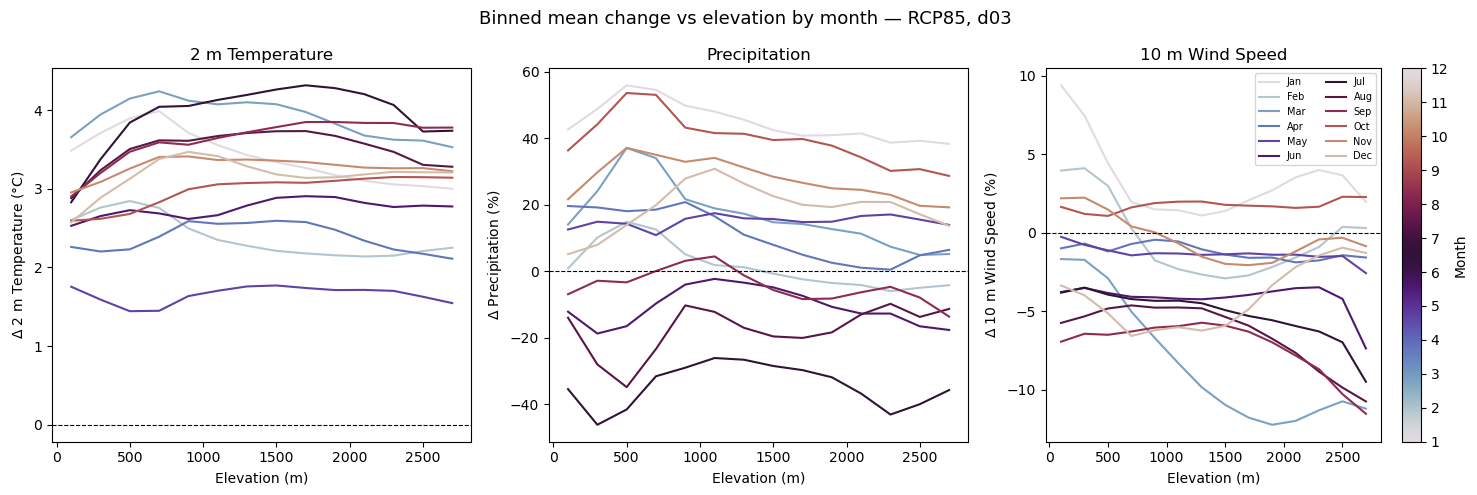

In [8]:
for variable in ['t', 'pr', 'wind']:
    cfg = variables[variable]
    delta, _ = load_delta(variable, period, domain)

    fig, axes = plt.subplots(3, 4, figsize=(18, 12), sharey=True, sharex=True)
    axes = axes.flatten()

    for kk in range(12):
        ax = axes[kk]
        delta_mo = delta[kk, :, :]

        centres, means, stds, counts = bin_by_elevation(
            delta_mo, elevation, land_mask, bin_size=bin_size
        )

        # Raw scatter
        elev_flat  = elevation[land_mask].flatten()
        delta_flat = delta_mo[land_mask].flatten()
        ax.scatter(elev_flat, delta_flat, alpha=0.08, s=1, color='grey', rasterized=True)

        # Binned mean ± 1 std
        ax.plot(centres, means, color='red', linewidth=1.5)
        ax.fill_between(centres,
                        means - stds,
                        means + stds,
                        alpha=0.3, color='red')

        ax.axhline(0, color='black', linestyle='--', linewidth=0.8)
        ax.set_title(month_names[kk])

        if kk % 4 == 0:
            ax.set_ylabel(f'$\\Delta$ ({cfg["units"]})')
        if kk >= 8:
            ax.set_xlabel('Elevation (m)')

    fig.suptitle(
        f'{cfg["label"]} change vs elevation by month — {period.upper()}, {domain}',
        fontsize=13
    )
    plt.tight_layout()
    plt.savefig(f'delta_vs_elevation_monthly_{variable}_{period}_{domain}.png', dpi=150)
    plt.show()

# %% [markdown]
# ## Summary: Binned Mean per Month (line plot)
# All months on one axis per variable — shows seasonal cycle of elevation dependence

# %%
cmap   = plt.cm.twilight
colors = [cmap(i / 12) for i in range(12)]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, variable in zip(axes, ['t', 'pr', 'wind']):
    cfg = variables[variable]
    delta, _ = load_delta(variable, period, domain)

    for kk in range(12):
        centres, means, stds, _ = bin_by_elevation(
            delta[kk], elevation, land_mask, bin_size=bin_size
        )
        ax.plot(centres, means, color=colors[kk], linewidth=1.5, label=month_names[kk])

    ax.axhline(0, color='black', linestyle='--', linewidth=0.8)
    ax.set_xlabel('Elevation (m)')
    ax.set_ylabel(f'$\\Delta$ {cfg["label"]} ({cfg["units"]})')
    ax.set_title(cfg['label'])

axes[-1].legend(fontsize=7, ncol=2, loc='upper right')
sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(1, 12))
sm.set_array([])
fig.colorbar(sm, ax=axes[-1], label='Month', ticks=range(1, 13))

fig.suptitle(f'Binned mean change vs elevation by month — {period.upper()}, {domain}', fontsize=13)
plt.tight_layout()
#plt.savefig(f'delta_vs_elevation_summary_{period}_{domain}.png', dpi=150)
plt.show()